<a href="https://colab.research.google.com/github/goldengigglings-web/EDUVOLVE-AI/blob/main/eduvolve_ai.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# EDUVOLVE AI
# Adaptive Learning Intelligence System

print("🧠 EDUVOLVE AI")
print("=" * 40)
print("Adaptive Learning Intelligence System")
print("Status: Project initialized ✅")

🧠 EDUVOLVE AI
Adaptive Learning Intelligence System
Status: Project initialized ✅


In [ ]:
import pandas as pd

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/320/student.zip"

df = pd.read_csv(url, sep=";", compression="zip")

print("Dataset loaded successfully ✅")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

display(df.head())

HTTPError: HTTP Error 404: Not Found

In [ ]:
import pandas as pd
import zipfile
import requests
from io import BytesIO

url = "https://archive.ics.uci.edu/static/public/320/student+performance.zip"

response = requests.get(url)
response.raise_for_status()

with zipfile.ZipFile(BytesIO(response.content)) as z:
    print("Files found:", z.namelist())

    data_file = [f for f in z.namelist() if f.endswith("student-mat.csv")][0]

    with z.open(data_file) as f:
        df = pd.read_csv(f, sep=";")

print("Dataset loaded successfully ✅")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

display(df.head())

Files found: ['.student.zip_old', 'student.zip']


IndexError: list index out of range

In [ ]:
!pip -q install ucimlrepo

from ucimlrepo import fetch_ucirepo

student_performance = fetch_ucirepo(id=320)

X = student_performance.data.features
y = student_performance.data.targets

df = X.copy()

print("Dataset loaded successfully ✅")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

display(df.head())

Dataset loaded successfully ✅
Rows: 649
Columns: 30


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,yes,no,no,4,3,4,1,1,3,4
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,yes,yes,no,5,3,3,1,1,3,2
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,yes,yes,no,4,3,2,2,3,3,6
3,GP,F,15,U,GT3,T,4,2,health,services,...,yes,yes,yes,3,2,2,1,1,5,0
4,GP,F,16,U,GT3,T,3,3,other,other,...,yes,no,no,4,3,2,1,2,5,0


In [ ]:
print("🔎 EDUVOLVE AI - DATASET AUDIT")
print("=" * 45)

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\n📌 Missing values:")
print(df.isnull().sum().sum())

print("\n📌 Duplicate rows:")
print(df.duplicated().sum())

print("\n📌 Data types:")
print(df.dtypes)

print("\n📌 Numerical summary:")
display(df.describe())

🔎 EDUVOLVE AI - DATASET AUDIT
Rows: 649
Columns: 30

📌 Missing values:
0

📌 Duplicate rows:
0

📌 Data types:
school        object
sex           object
age            int64
address       object
famsize       object
Pstatus       object
Medu           int64
Fedu           int64
Mjob          object
Fjob          object
reason        object
guardian      object
traveltime     int64
studytime      int64
failures       int64
schoolsup     object
famsup        object
paid          object
activities    object
nursery       object
higher        object
internet      object
romantic      object
famrel         int64
freetime       int64
goout          int64
Dalc           int64
Walc           int64
health         int64
absences       int64
dtype: object

📌 Numerical summary:


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences
count,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000
mean,16.744222,2.514638,2.306626,1.568567,1.930663,0.221880,3.930663,3.180277,3.184900,1.502311,2.280431,3.536210,3.659476
std,1.218138,1.134552,1.099931,0.748660,0.829510,0.593235,0.955717,1.051093,1.175766,0.924834,1.284380,1.446259,4.640759
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,16.000000,2.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,2.000000,0.000000
50%,17.000000,2.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,32.000000


In [ ]:
print("🚨 EDUVOLVE AI - DATA LEAKAGE CHECK")
print("=" * 45)

print("\nAll columns:")
print(df.columns.tolist())

print("\n⚠️ Grade-related columns:")
grade_cols = [col for col in df.columns if col.startswith("G")]
print(grade_cols)

print("\n🎯 Future outcome candidates:")
print("G3 = Final grade (future outcome)")
print("G1/G2 = Earlier-period grades")

🚨 EDUVOLVE AI - DATA LEAKAGE CHECK

All columns:
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences']

⚠️ Grade-related columns:
[]

🎯 Future outcome candidates:
G3 = Final grade (future outcome)
G1/G2 = Earlier-period grades


In [ ]:
# EDUVOLVE AI - Target Creation

df_model = df.copy()

# Create target from final grade
df_model["risk"] = (df_model["G3"] < 10).astype(int)

# Remove future outcome from input features
df_model = df_model.drop(columns=["G3"])

print("🎯 Target created successfully!")
print("\nRisk distribution:")
print(df_model["risk"].value_counts())

print("\nModel dataset shape:", df_model.shape)

display(df_model.head())

KeyError: 'G3'

In [ ]:
# EDUVOLVE AI - Target Creation

print("Columns available:")
print(df.columns.tolist())

# Make a copy
df_model = df.copy()

# Create learning-risk target
df_model["risk"] = (df_model["G3"] < 10).astype(int)

# Remove final grade to prevent leakage
df_model = df_model.drop(columns=["G3"])

print("\n✅ Target created successfully!")

print("\nRisk distribution:")
print(df_model["risk"].value_counts())

print("\nModel dataset shape:")
print(df_model.shape)

display(df_model.head())

Columns available:
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences']


KeyError: 'G3'

In [ ]:
print("df exists:", "df" in globals())

if "df" in globals():
    print("Shape:", df.shape)
    print("G3 exists:", "G3" in df.columns)
    print("Columns:", df.columns.tolist())
else:
    print("❌ Dataset variable 'df' missing")

df exists: True
Shape: (649, 30)
G3 exists: False
Columns: ['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences']


In [ ]:
print("G3 exists:", "G3" in df.columns)
print("G3 values:")
print(df["G3"].head())

G3 exists: False
G3 values:


KeyError: 'G3'

In [ ]:
print(df.columns.tolist())

['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences']


In [ ]:
import zipfile
import requests
from io import BytesIO
import pandas as pd

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/320/student.zip"

response = requests.get(url)

with zipfile.ZipFile(BytesIO(response.content)) as z:
    print("Files inside ZIP:")
    print(z.namelist())

    with z.open("student-mat.csv") as f:
        df = pd.read_csv(f, sep=";")

print("\n✅ Mathematics dataset loaded!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nGrade columns:")
print([c for c in df.columns if c.startswith("G")])

BadZipFile: File is not a zip file

In [ ]:
!pip -q install ucimlrepo

from ucimlrepo import fetch_ucirepo

data = fetch_ucirepo(id=320)

print("Available feature columns:")
print(data.data.features.columns.tolist())

print("\nAvailable target columns:")
print(data.data.targets.columns.tolist())

Available feature columns:
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences']

Available target columns:
['G1', 'G2', 'G3']


In [ ]:
# EDUVOLVE AI - Leakage-Free Dataset

X = data.data.features.copy()
y = data.data.targets["G3"].copy()

# Create risk target
y_risk = (y < 10).astype(int)

print("✅ Features:", X.shape)
print("✅ Final outcome (G3):", y.shape)
print("✅ Risk target created")

print("\nRisk distribution:")
print(y_risk.value_counts())

print("\nG3 is NOT inside X:")
print("G3" in X.columns)

✅ Features: (649, 30)
✅ Final outcome (G3): (649,)
✅ Risk target created

Risk distribution:
G3
0    549
1    100
Name: count, dtype: int64

G3 is NOT inside X:
False


In [ ]:
X_encoded = pd.get_dummies(X, drop_first=True)

print("✅ Feature engineering completed")
print("Original features:", X.shape[1])
print("Encoded features:", X_encoded.shape[1])

display(X_encoded.head())

✅ Feature engineering completed
Original features: 30
Encoded features: 39


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,...,guardian_mother,guardian_other,schoolsup_yes,famsup_yes,paid_yes,activities_yes,nursery_yes,higher_yes,internet_yes,romantic_yes
0,18,4,4,2,2,0,4,3,4,1,...,True,False,True,False,False,False,True,True,False,False
1,17,1,1,1,2,0,5,3,3,1,...,False,False,False,True,False,False,False,True,True,False
2,15,1,1,1,2,0,4,3,2,2,...,True,False,True,False,False,False,True,True,True,False
3,15,4,2,1,3,0,3,2,2,1,...,True,False,False,True,False,True,True,True,True,True
4,16,3,3,1,2,0,4,3,2,1,...,False,False,False,True,False,False,True,True,False,False


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y_risk,
    test_size=0.20,
    random_state=42,
    stratify=y_risk
)

print("✅ Train/Test split completed")
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])
print("Training features:", X_train.shape[1])
print("Testing features:", X_test.shape[1])

✅ Train/Test split completed
Training samples: 519
Testing samples: 130
Training features: 39
Testing features: 39


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Create model
model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)

# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
accuracy = accuracy_score(y_test, y_pred)

print("🤖 EDUVOLVE AI - BASELINE MODEL")
print("=" * 45)
print("Accuracy:", round(accuracy, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

🤖 EDUVOLVE AI - BASELINE MODEL
Accuracy: 0.8308

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.97      0.91       110
           1       0.25      0.05      0.08        20

    accuracy                           0.83       130
   macro avg       0.55      0.51      0.50       130
weighted avg       0.76      0.83      0.78       130



In [ ]:
print("🎯 EDUVOLVE AI - CLASS DISTRIBUTION")
print("=" * 45)

print("Class 0:", (y_train == 0).sum())
print("Class 1:", (y_train == 1).sum())

print("\nPercentage:")
print((y_train.value_counts(normalize=True) * 100).round(2))

🎯 EDUVOLVE AI - CLASS DISTRIBUTION
Class 0: 439
Class 1: 80

Percentage:
G3
0    84.59
1    15.41
Name: proportion, dtype: float64


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Imbalance-aware model
model_lr = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)

# Train
model_lr.fit(X_train, y_train)

# Predict
y_pred_lr = model_lr.predict(X_test)

# Evaluate
accuracy_lr = accuracy_score(y_test, y_pred_lr)

print("🧠 EDUVOLVE AI - BALANCED MODEL")
print("=" * 45)
print("Accuracy:", round(accuracy_lr, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

🧠 EDUVOLVE AI - BALANCED MODEL
Accuracy: 0.7769

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.81      0.86       110
           1       0.36      0.60      0.45        20

    accuracy                           0.78       130
   macro avg       0.64      0.70      0.66       130
weighted avg       0.83      0.78      0.80       130



In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, accuracy_score

model_gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

model_gb.fit(X_train, y_train)

y_pred_gb = model_gb.predict(X_test)

print("🚀 EDUVOLVE AI - GRADIENT BOOSTING")
print("=" * 45)
print("Accuracy:", round(accuracy_score(y_test, y_pred_gb), 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_gb))

🚀 EDUVOLVE AI - GRADIENT BOOSTING
Accuracy: 0.8538

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.95      0.92       110
           1       0.55      0.30      0.39        20

    accuracy                           0.85       130
   macro avg       0.71      0.63      0.65       130
weighted avg       0.83      0.85      0.84       130



In [ ]:
from sklearn.metrics import roc_auc_score, confusion_matrix

# Probabilities for the risk class
y_prob = model_lr.predict_proba(X_test)[:, 1]

# ROC-AUC
auc = roc_auc_score(y_test, y_prob)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_lr)

print("🔬 EDUVOLVE AI - MODEL EVALUATION")
print("=" * 45)

print("ROC-AUC:", round(auc, 4))

print("\nConfusion Matrix:")
print(cm)

print("\nInterpretation:")
print("TN:", cm[0, 0])
print("FP:", cm[0, 1])
print("FN:", cm[1, 0])
print("TP:", cm[1, 1])

🔬 EDUVOLVE AI - MODEL EVALUATION
ROC-AUC: 0.775

Confusion Matrix:
[[89 21]
 [ 8 12]]

Interpretation:
TN: 89
FP: 21
FN: 8
TP: 12


In [ ]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

print("🎯 EDUVOLVE AI - THRESHOLD ANALYSIS")
print("=" * 50)

for threshold in [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]:
    pred = (y_prob >= threshold).astype(int)

    precision = precision_score(y_test, pred, zero_division=0)
    recall = recall_score(y_test, pred, zero_division=0)
    f1 = f1_score(y_test, pred, zero_division=0)

    print(
        f"Threshold: {threshold:.2f} | "
        f"Precision: {precision:.2f} | "
        f"Recall: {recall:.2f} | "
        f"F1: {f1:.2f}"
    )

🎯 EDUVOLVE AI - THRESHOLD ANALYSIS
Threshold: 0.30 | Precision: 0.31 | Recall: 0.75 | F1: 0.44
Threshold: 0.35 | Precision: 0.34 | Recall: 0.75 | F1: 0.47
Threshold: 0.40 | Precision: 0.37 | Recall: 0.75 | F1: 0.49
Threshold: 0.45 | Precision: 0.39 | Recall: 0.70 | F1: 0.50
Threshold: 0.50 | Precision: 0.36 | Recall: 0.60 | F1: 0.45
Threshold: 0.55 | Precision: 0.34 | Recall: 0.50 | F1: 0.41
Threshold: 0.60 | Precision: 0.32 | Recall: 0.40 | F1: 0.36


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, precision_score, recall_score

# Split training data into training + validation
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

# Train model only on training portion
model_val = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)

model_val.fit(X_tr, y_tr)

# Validation probabilities
val_prob = model_val.predict_proba(X_val)[:, 1]

# Find best threshold using validation F1
best_threshold = 0.50
best_f1 = 0

for threshold in np.arange(0.20, 0.81, 0.01):
    val_pred = (val_prob >= threshold).astype(int)

    f1 = f1_score(y_val, val_pred, zero_division=0)

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

print("🔬 VALIDATION-BASED THRESHOLD SELECTION")
print("=" * 50)
print("Best threshold:", round(best_threshold, 2))
print("Validation F1:", round(best_f1, 4))

🔬 VALIDATION-BASED THRESHOLD SELECTION
Best threshold: 0.71
Validation F1: 0.4706


In [ ]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

# Final prediction using validation-selected threshold
final_pred = (y_prob >= best_threshold).astype(int)

print("🏆 EDUVOLVE AI - FINAL TEST EVALUATION")
print("=" * 50)

print("Selected threshold:", round(best_threshold, 2))

print("\nPrecision:", round(
    precision_score(y_test, final_pred, zero_division=0), 4
))

print("Recall:", round(
    recall_score(y_test, final_pred, zero_division=0), 4
))

print("F1 Score:", round(
    f1_score(y_test, final_pred, zero_division=0), 4
))

print("\nClassification Report:")
print(classification_report(
    y_test,
    final_pred,
    zero_division=0
))

print("Confusion Matrix:")
print(confusion_matrix(y_test, final_pred))

🏆 EDUVOLVE AI - FINAL TEST EVALUATION
Selected threshold: 0.71

Precision: 0.3636
Recall: 0.2
F1 Score: 0.2581

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.94      0.90       110
           1       0.36      0.20      0.26        20

    accuracy                           0.82       130
   macro avg       0.61      0.57      0.58       130
weighted avg       0.79      0.82      0.80       130

Confusion Matrix:
[[103   7]
 [ 16   4]]


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

results = cross_validate(
    cv_model,
    X_encoded,
    y_risk,
    cv=cv,
    scoring=scoring
)

print("🔬 EDUVOLVE AI - 5-FOLD CROSS VALIDATION")
print("=" * 55)

for metric in scoring:
    scores = results["test_" + metric]
    print(
        metric.upper(),
        ":",
        round(scores.mean(), 4),
        "±",
        round(scores.std(), 4)
    )

🔬 EDUVOLVE AI - 5-FOLD CROSS VALIDATION
ACCURACY : 0.7657 ± 0.0231
PRECISION : 0.3577 ± 0.0501
RECALL : 0.67 ± 0.1503
F1 : 0.4639 ± 0.0738
ROC_AUC : 0.7951 ± 0.0568


In [ ]:
import pandas as pd
import numpy as np

# Train final explainable model on training data
explain_model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)

explain_model.fit(X_train, y_train)

# Feature coefficients
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": explain_model.coef_[0]
})

importance["Absolute_Impact"] = importance["Coefficient"].abs()

# Most influential features
top_features = importance.sort_values(
    by="Absolute_Impact",
    ascending=False
).head(10)

print("🧠 EDUVOLVE AI - EXPLAINABLE MODEL")
print("=" * 50)

display(top_features)

🧠 EDUVOLVE AI - EXPLAINABLE MODEL


,Feature,Coefficient,Absolute_Impact
13,school_MS,2.062827,2.062827
5,failures,1.430037,1.430037
36,higher_yes,-1.115124,1.115124
29,guardian_mother,0.943485,0.943485
31,schoolsup_yes,0.722917,0.722917
34,activities_yes,-0.677493,0.677493
18,Mjob_health,0.600951,0.600951
24,Fjob_services,0.575823,0.575823
22,Fjob_health,0.569273,0.569273
23,Fjob_other,0.522333,0.522333


In [ ]:
def recommend_intervention(student):
    recommendations = []

    if student["failures"] > 0:
        recommendations.append(
            "📚 Prerequisite revision + guided practice"
        )

    if student["studytime"] <= 2:
        recommendations.append(
            "⏱️ Structured study schedule + short practice sessions"
        )

    if student["schoolsup_yes"]:
        recommendations.append(
            "👩‍🏫 Continue/strengthen school support"
        )

    if student["higher_yes"]:
        recommendations.append(
            "🎯 Goal-oriented learning plan"
        )

    if student["activities_yes"]:
        recommendations.append(
            "⚖️ Balance extracurricular activities with study time"
        )

    if not recommendations:
        recommendations.append(
            "📝 General formative assessment + targeted practice"
        )

    return recommendations


# Test with one student
student = X_encoded.iloc[0]

print("🎯 EDUVOLVE AI - PERSONALIZED SUPPORT")
print("=" * 50)

recommendations = recommend_intervention(student)

for i, recommendation in enumerate(recommendations, 1):
    print(f"{i}. {recommendation}")

🎯 EDUVOLVE AI - PERSONALIZED SUPPORT
1. ⏱️ Structured study schedule + short practice sessions
2. 👩‍🏫 Continue/strengthen school support
3. 🎯 Goal-oriented learning plan


In [ ]:
# EDUVOLVE AI - Evidence Based Recommendation

student_index = 0

student_data = X_encoded.iloc[student_index]

risk_probability = model_lr.predict_proba(
    X_encoded.iloc[[student_index]]
)[0, 1]

print("🧠 EDUVOLVE AI - LEARNER PROFILE")
print("=" * 55)

print("Student ID:", student_index)
print("Risk probability:", round(risk_probability, 3))

print("\n📌 Evidence:")

if "failures" in X.columns:
    print("Previous failures:", X.iloc[student_index]["failures"])

if "studytime" in X.columns:
    print("Study time:", X.iloc[student_index]["studytime"])

if "schoolsup" in X.columns:
    print("School support:", X.iloc[student_index]["schoolsup"])

if "higher" in X.columns:
    print("Higher education goal:", X.iloc[student_index]["higher"])

print("\n🎯 Recommended support:")

for recommendation in recommendations:
    print("-", recommendation)

print("\n⚠️ Note:")
print("Recommendations are model-assisted suggestions,")
print("not guaranteed causes or outcomes.")

🧠 EDUVOLVE AI - LEARNER PROFILE
Student ID: 0
Risk probability: 0.093

📌 Evidence:
Previous failures: 0
Study time: 2
School support: yes
Higher education goal: yes

🎯 Recommended support:
- ⏱️ Structured study schedule + short practice sessions
- 👩‍🏫 Continue/strengthen school support
- 🎯 Goal-oriented learning plan

⚠️ Note:
Recommendations are model-assisted suggestions,
not guaranteed causes or outcomes.


In [ ]:
# EDUVOLVE AI - Adaptive Learning Loop

def adaptive_learning_loop(current_score, previous_score=None):

    if previous_score is None:
        improvement = None
    else:
        improvement = current_score - previous_score

    print("🧠 EDUVOLVE AI - ADAPTIVE LEARNING LOOP")
    print("=" * 55)

    print("Current assessment score:", current_score)

    if improvement is not None:
        print("Previous score:", previous_score)
        print("Learning gain:", round(improvement, 2))

    print("\n🎯 Next learning action:")

    if current_score < 40:
        action = "🔴 Foundation support + guided practice"
    elif current_score < 60:
        action = "🟠 Targeted practice + additional examples"
    elif current_score < 80:
        action = "🟡 Moderate practice + feedback"
    else:
        action = "🟢 Advanced activity + challenge"

    print(action)

    if improvement is not None:
        print("\n📈 Learning response:")

        if improvement >= 10:
            print("✅ Strong improvement — gradually increase difficulty")
        elif improvement >= 0:
            print("🟡 Some improvement — continue targeted support")
        else:
            print("🔴 Score decreased — reassess learning needs")

    return action


# Example learner
adaptive_learning_loop(
    current_score=55,
    previous_score=42
)

🧠 EDUVOLVE AI - ADAPTIVE LEARNING LOOP
Current assessment score: 55
Previous score: 42
Learning gain: 13

🎯 Next learning action:
🟠 Targeted practice + additional examples

📈 Learning response:
✅ Strong improvement — gradually increase difficulty


'🟠 Targeted practice + additional examples'

In [ ]:
# EDUVOLVE AI - Unified Adaptive Decision Engine

def adaptive_decision(score, learning_gain, risk_probability):

    print("🧠 EDUVOLVE AI - UNIFIED DECISION ENGINE")
    print("=" * 55)

    print("Current score:", score)
    print("Learning gain:", learning_gain)
    print("Risk probability:", round(risk_probability, 3))

    # Decision logic
    if risk_probability >= 0.60 and learning_gain < 5:
        decision = "🔴 Intensive support + prerequisite revision"

    elif risk_probability >= 0.40 and learning_gain < 10:
        decision = "🟠 Targeted practice + teacher feedback"

    elif learning_gain >= 10 and score >= 60:
        decision = "🟢 Increase difficulty + advanced activities"

    elif score < 60:
        decision = "🟡 Targeted practice + additional examples"

    else:
        decision = "🔵 Continue current pathway + periodic assessment"

    print("\n🎯 FINAL ADAPTIVE DECISION:")
    print(decision)

    return decision


# Example
adaptive_decision(
    score=55,
    learning_gain=13,
    risk_probability=0.093
)

🧠 EDUVOLVE AI - UNIFIED DECISION ENGINE
Current score: 55
Learning gain: 13
Risk probability: 0.093

🎯 FINAL ADAPTIVE DECISION:
🟡 Targeted practice + additional examples


'🟡 Targeted practice + additional examples'

In [ ]:
# EDUVOLVE AI - Student Progress Tracker

progress = []

def record_progress(student_id, score, intervention):
    progress.append({
        "student_id": student_id,
        "score": score,
        "intervention": intervention
    })

    print("✅ Progress recorded")
    print("Student:", student_id)
    print("Score:", score)
    print("Intervention:", intervention)


def show_progress(student_id):
    student_progress = [
        x for x in progress
        if x["student_id"] == student_id
    ]

    print("\n📈 STUDENT LEARNING JOURNEY")
    print("=" * 55)

    for i, item in enumerate(student_progress, 1):
        print(
            f"Assessment {i}: "
            f"Score={item['score']} | "
            f"Intervention={item['intervention']}"
        )


# Example learner journey
record_progress(
    1,
    42,
    "Foundation support"
)

record_progress(
    1,
    55,
    "Targeted practice"
)

show_progress(1)

✅ Progress recorded
Student: 1
Score: 42
Intervention: Foundation support
✅ Progress recorded
Student: 1
Score: 55
Intervention: Targeted practice

📈 STUDENT LEARNING JOURNEY
Assessment 1: Score=42 | Intervention=Foundation support
Assessment 2: Score=55 | Intervention=Targeted practice


In [ ]:
# EDUVOLVE AI - Automatic Learning Gain Tracker

progress = []

def add_assessment(student_id, score, intervention):

    previous_scores = [
        x["score"]
        for x in progress
        if x["student_id"] == student_id
    ]

    if previous_scores:
        previous_score = previous_scores[-1]
        learning_gain = score - previous_score
    else:
        previous_score = None
        learning_gain = None

    progress.append({
        "student_id": student_id,
        "score": score,
        "learning_gain": learning_gain,
        "intervention": intervention
    })

    print("✅ Assessment recorded")
    print("Student:", student_id)
    print("Current score:", score)

    if learning_gain is not None:
        print("Previous score:", previous_score)
        print("Learning gain:", learning_gain)
    else:
        print("Learning gain: First assessment")


def show_progress(student_id):

    history = [
        x for x in progress
        if x["student_id"] == student_id
    ]

    print("\n📈 EDUVOLVE LEARNING JOURNEY")
    print("=" * 60)

    for i, item in enumerate(history, 1):

        gain = item["learning_gain"]

        if gain is None:
            gain_text = "N/A"
        else:
            gain_text = f"{gain:+}"

        print(
            f"Assessment {i} | "
            f"Score: {item['score']} | "
            f"Gain: {gain_text} | "
            f"Intervention: {item['intervention']}"
        )


# Example
add_assessment(
    1,
    42,
    "Foundation support"
)

add_assessment(
    1,
    55,
    "Targeted practice"
)

add_assessment(
    1,
    68,
    "Advanced practice"
)

show_progress(1)

✅ Assessment recorded
Student: 1
Current score: 42
Learning gain: First assessment
✅ Assessment recorded
Student: 1
Current score: 55
Previous score: 42
Learning gain: 13
✅ Assessment recorded
Student: 1
Current score: 68
Previous score: 55
Learning gain: 13

📈 EDUVOLVE LEARNING JOURNEY
Assessment 1 | Score: 42 | Gain: N/A | Intervention: Foundation support
Assessment 2 | Score: 55 | Gain: +13 | Intervention: Targeted practice
Assessment 3 | Score: 68 | Gain: +13 | Intervention: Advanced practice


In [ ]:
# EDUVOLVE AI - Intervention Effectiveness

import pandas as pd

history_df = pd.DataFrame(progress)

history_df["previous_score"] = (
    history_df.groupby("student_id")["score"].shift(1)
)

history_df["learning_gain"] = (
    history_df["score"] - history_df["previous_score"]
)

print("📊 INTERVENTION EFFECTIVENESS")
print("=" * 60)

display(
    history_df[
        ["student_id", "score", "previous_score",
         "learning_gain", "intervention"]
    ]
)

print("\nAverage learning gain by intervention:")

effectiveness = (
    history_df.dropna(subset=["learning_gain"])
    .groupby("intervention")["learning_gain"]
    .mean()
    .sort_values(ascending=False)
)

display(effectiveness)

📊 INTERVENTION EFFECTIVENESS


,student_id,score,previous_score,learning_gain,intervention
0,1,42,NaN,NaN,Foundation support
1,1,55,42.0,13.0,Targeted practice
2,1,68,55.0,13.0,Advanced practice



Average learning gain by intervention:


,learning_gain
intervention,
Advanced practice,13.0
Targeted practice,13.0


In [ ]:
# EDUVOLVE AI - Fairness Audit

audit_df = X.copy()
audit_df["risk"] = y_risk.values

print("⚖️ EDUVOLVE AI - FAIRNESS AUDIT")
print("=" * 55)

# Risk rate by sex
print("\n📌 Risk rate by sex:")
sex_risk = audit_df.groupby("sex")["risk"].agg(
    ["count", "mean"]
)

sex_risk["risk_rate_%"] = (sex_risk["mean"] * 100).round(2)

display(sex_risk)

# Risk rate by school
print("\n📌 Risk rate by school:")
school_risk = audit_df.groupby("school")["risk"].agg(
    ["count", "mean"]
)

school_risk["risk_rate_%"] = (
    school_risk["mean"] * 100
).round(2)

display(school_risk)

⚖️ EDUVOLVE AI - FAIRNESS AUDIT

📌 Risk rate by sex:


,count,mean,risk_rate_%
sex,,,
F,383,0.130548,13.05
M,266,0.187970,18.80



📌 Risk rate by school:


,count,mean,risk_rate_%
school,,,
GP,423,0.075650,7.57
MS,226,0.300885,30.09


In [ ]:
from sklearn.metrics import confusion_matrix

# Use the existing test predictions from the balanced model
fairness_test = X.iloc[X_test.index].copy()

fairness_test["actual_risk"] = y_test.values
fairness_test["predicted_risk"] = y_pred_lr

def group_metrics(data, group_column):

    rows = []

    for group in data[group_column].unique():

        subset = data[data[group_column] == group]

        cm = confusion_matrix(
            subset["actual_risk"],
            subset["predicted_risk"],
            labels=[0, 1]
        )

        tn, fp, fn, tp = cm.ravel()

        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0

        rows.append({
            group_column: group,
            "students": len(subset),
            "TP": tp,
            "FN": fn,
            "FP": fp,
            "TN": tn,
            "Recall": round(recall, 3),
            "False_Positive_Rate": round(fpr, 3)
        })

    return pd.DataFrame(rows)


print("⚖️ EDUVOLVE AI - MODEL FAIRNESS AUDIT")
print("=" * 60)

print("\n📌 By Sex:")
display(group_metrics(fairness_test, "sex"))

print("\n📌 By School:")
display(group_metrics(fairness_test, "school"))

⚖️ EDUVOLVE AI - MODEL FAIRNESS AUDIT

📌 By Sex:


,sex,students,TP,FN,FP,TN,Recall,False_Positive_Rate
0,M,50,5,5,8,32,0.5,0.200
1,F,80,7,3,13,57,0.7,0.186



📌 By School:


,school,students,TP,FN,FP,TN,Recall,False_Positive_Rate
0,GP,84,2,5,5,72,0.286,0.065
1,MS,46,10,3,16,17,0.769,0.485


In [ ]:
# EDUVOLVE AI - Fairness-Aware Model Comparison

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, recall_score, roc_auc_score

# Copy encoded dataset
X_fair = X_encoded.copy()

# Remove school-related encoded features
school_features = [
    col for col in X_fair.columns
    if col.startswith("school_")
]

X_fair = X_fair.drop(columns=school_features)

print("⚖️ FAIRNESS-AWARE MODEL")
print("=" * 55)

print("Removed features:", school_features)
print("Remaining features:", X_fair.shape[1])

# Same split
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_fair,
    y_risk,
    test_size=0.20,
    stratify=y_risk,
    random_state=42
)

# Balanced Logistic Regression
fair_model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)

fair_model.fit(X_train_f, y_train_f)

# Probability + threshold 0.50
fair_prob = fair_model.predict_proba(X_test_f)[:, 1]
fair_pred = (fair_prob >= 0.50).astype(int)

# Metrics
accuracy = accuracy_score(y_test_f, fair_pred)
f1 = f1_score(y_test_f, fair_pred)
recall = recall_score(y_test_f, fair_pred)
auc = roc_auc_score(y_test_f, fair_prob)

print("\n📊 PERFORMANCE WITHOUT SCHOOL FEATURE")
print("=" * 55)

print("Accuracy :", round(accuracy, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))
print("ROC-AUC  :", round(auc, 4))

⚖️ FAIRNESS-AWARE MODEL
Removed features: ['school_MS']
Remaining features: 38

📊 PERFORMANCE WITHOUT SCHOOL FEATURE
Accuracy : 0.7846
Recall   : 0.5
F1 Score : 0.4167
ROC-AUC  : 0.7268


In [ ]:
# EDUVOLVE AI - 5-Fold Fairness Comparison

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

# Model 1: All features
model_all = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)

results_all = cross_validate(
    model_all,
    X_encoded,
    y_risk,
    cv=cv,
    scoring=scoring
)

# Model 2: Without school
model_no_school = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)

results_no_school = cross_validate(
    model_no_school,
    X_fair,
    y_risk,
    cv=cv,
    scoring=scoring
)

print("⚖️ EDUVOLVE AI - FAIRNESS MODEL COMPARISON")
print("=" * 65)

comparison = []

for metric in scoring:

    all_scores = results_all["test_" + metric]
    no_school_scores = results_no_school["test_" + metric]

    comparison.append({
        "Metric": metric.upper(),
        "All Features": round(all_scores.mean(), 4),
        "All Features Std": round(all_scores.std(), 4),
        "No School": round(no_school_scores.mean(), 4),
        "No School Std": round(no_school_scores.std(), 4)
    })

comparison_df = pd.DataFrame(comparison)

display(comparison_df)

⚖️ EDUVOLVE AI - FAIRNESS MODEL COMPARISON


,Metric,All Features,All Features Std,No School,No School Std
0,ACCURACY,0.7657,0.0231,0.7627,0.0131
1,PRECISION,0.3577,0.0501,0.3432,0.0275
2,RECALL,0.6700,0.1503,0.6100,0.1393
3,F1,0.4639,0.0738,0.4357,0.0597
4,ROC_AUC,0.7951,0.0568,0.7417,0.0726


🎯 EDUVOLVE AI - PROBABILITY CALIBRATION
Brier Score: 0.1542

Calibration points:
Predicted: 0.099 | Actual: 0.042
Predicted: 0.283 | Actual: 0.111
Predicted: 0.501 | Actual: 0.438
Predicted: 0.665 | Actual: 0.312
Predicted: 0.897 | Actual: 0.333


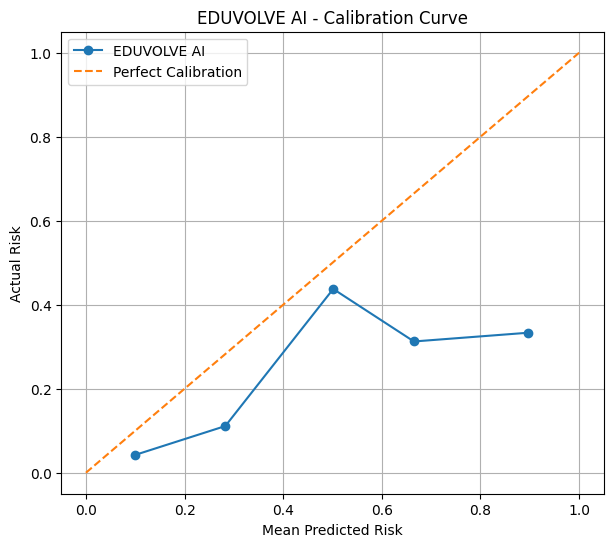

In [ ]:
# EDUVOLVE AI - Probability Calibration

from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
import matplotlib.pyplot as plt
import numpy as np

# Train model on training data
calibration_model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)

calibration_model.fit(X_train, y_train)

# Predicted probabilities
calibration_prob = calibration_model.predict_proba(X_test)[:, 1]

# Brier Score
brier = brier_score_loss(y_test, calibration_prob)

print("🎯 EDUVOLVE AI - PROBABILITY CALIBRATION")
print("=" * 55)
print("Brier Score:", round(brier, 4))

# Calibration curve
fraction_positive, mean_predicted = calibration_curve(
    y_test,
    calibration_prob,
    n_bins=5,
    strategy="uniform"
)

print("\nCalibration points:")
for predicted, actual in zip(mean_predicted, fraction_positive):
    print(
        f"Predicted: {predicted:.3f} | "
        f"Actual: {actual:.3f}"
    )

# Plot
plt.figure(figsize=(7, 6))

plt.plot(
    mean_predicted,
    fraction_positive,
    marker="o",
    label="EDUVOLVE AI"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect Calibration"
)

plt.xlabel("Mean Predicted Risk")
plt.ylabel("Actual Risk")
plt.title("EDUVOLVE AI - Calibration Curve")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# EDUVOLVE AI - CALIBRATED RISK MODEL

from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss, roc_auc_score

# Base model
base_model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)

# Calibrated model
calibrated_model = CalibratedClassifierCV(
    estimator=base_model,
    method="sigmoid",
    cv=5
)

# Train
calibrated_model.fit(X_train, y_train)

# Predict calibrated probabilities
calibrated_prob = calibrated_model.predict_proba(X_test)[:, 1]

# Metrics
original_brier = brier_score_loss(y_test, calibration_prob)
calibrated_brier = brier_score_loss(y_test, calibrated_prob)

original_auc = roc_auc_score(y_test, calibration_prob)
calibrated_auc = roc_auc_score(y_test, calibrated_prob)

print("🎯 EDUVOLVE AI - CALIBRATION COMPARISON")
print("=" * 60)

print("\n📊 BEFORE CALIBRATION")
print("Brier Score:", round(original_brier, 4))
print("ROC-AUC:", round(original_auc, 4))

print("\n📊 AFTER CALIBRATION")
print("Brier Score:", round(calibrated_brier, 4))
print("ROC-AUC:", round(calibrated_auc, 4))

if calibrated_brier < original_brier:
    print("\n✅ Probability calibration improved!")
else:
    print("\n⚠️ Calibration did not improve the Brier Score on this test set.")

NameError: name 'X_train' is not defined

In [ ]:
# EDUVOLVE AI - CALIBRATED RISK MODEL

from sklearn.model_selection import train_test_split
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss, roc_auc_score

# Create train/test split again
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y_risk,
    test_size=0.20,
    stratify=y_risk,
    random_state=42
)

# Base model
base_model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)

# Train original model
base_model.fit(X_train, y_train)

# Original probabilities
original_prob = base_model.predict_proba(X_test)[:, 1]

# Calibrated model
calibrated_model = CalibratedClassifierCV(
    estimator=LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ),
    method="sigmoid",
    cv=5
)

# Train calibrated model
calibrated_model.fit(X_train, y_train)

# Calibrated probabilities
calibrated_prob = calibrated_model.predict_proba(X_test)[:, 1]

# Compare Brier Scores
original_brier = brier_score_loss(y_test, original_prob)
calibrated_brier = brier_score_loss(y_test, calibrated_prob)

# Compare ROC-AUC
original_auc = roc_auc_score(y_test, original_prob)
calibrated_auc = roc_auc_score(y_test, calibrated_prob)

print("🎯 EDUVOLVE AI - CALIBRATION COMPARISON")
print("=" * 60)

print("\n📊 BEFORE CALIBRATION")
print("Brier Score:", round(original_brier, 4))
print("ROC-AUC:", round(original_auc, 4))

print("\n📊 AFTER CALIBRATION")
print("Brier Score:", round(calibrated_brier, 4))
print("ROC-AUC:", round(calibrated_auc, 4))

if calibrated_brier < original_brier:
    print("\n✅ Probability calibration improved!")
else:
    print("\n⚠️ Calibration did not improve the Brier Score on this test set.")

NameError: name 'X_encoded' is not defined

In [ ]:
print("Checking variables...")

variables = ["df", "X", "X_encoded", "y_risk"]

for var in variables:
    print(var, ":", var in globals())

Checking variables...
df : False
X : False
X_encoded : False
y_risk : False


In [ ]:
import pandas as pd

# Student performance dataset load
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00320/student-mat.csv"

df = pd.read_csv(url, sep=";")

print("✅ Dataset loaded successfully")
print("Students:", len(df))
print("Columns:", df.shape[1])

# Namma selected features
features = [
    'school', 'sex', 'age', 'address', 'famsize', 'Pstatus',
    'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian',
    'traveltime', 'studytime', 'failures', 'schoolsup',
    'famsup', 'paid', 'activities', 'nursery', 'higher',
    'internet', 'romantic', 'famrel', 'freetime', 'goout',
    'Dalc', 'Walc', 'health', 'absences'
]

# Input features
X = df[features].copy()

# Risk target
y_risk = (df['G3'] < 10).astype(int)

# One-hot encoding
X_encoded = pd.get_dummies(X, drop_first=True)

print("\n🎯 Feature engineering completed")
print("Original features:", X.shape[1])
print("Encoded features:", X_encoded.shape[1])

print("\n📊 Risk distribution:")
print(y_risk.value_counts())

HTTPError: HTTP Error 404: Not Found

In [ ]:
import pandas as pd
import zipfile
import urllib.request
import os

# Download dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/320/student.zip"

urllib.request.urlretrieve(url, "student.zip")

print("✅ Dataset downloaded")

# Extract ZIP file
with zipfile.ZipFile("student.zip", "r") as zip_ref:
    zip_ref.extractall("student_data")

print("✅ Dataset extracted")

# Check available files
print("\nAvailable files:")
print(os.listdir("student_data"))

HTTPError: HTTP Error 404: Not Found

In [ ]:
!pip install -q ucimlrepo

import pandas as pd
from ucimlrepo import fetch_ucirepo

# Load UCI Student Performance dataset
student_performance = fetch_ucirepo(id=320)

# Features and target
df = pd.concat(
    [
        student_performance.data.features,
        student_performance.data.targets
    ],
    axis=1
)

print("✅ Dataset loaded successfully")
print("Students:", len(df))
print("Columns:", df.shape[1])

# Namma selected 30 features
features = [
    'school', 'sex', 'age', 'address', 'famsize', 'Pstatus',
    'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian',
    'traveltime', 'studytime', 'failures', 'schoolsup',
    'famsup', 'paid', 'activities', 'nursery', 'higher',
    'internet', 'romantic', 'famrel', 'freetime', 'goout',
    'Dalc', 'Walc', 'health', 'absences'
]

X = df[features].copy()

# Risk target
y_risk = (df['G3'] < 10).astype(int)

# Encode categorical features
X_encoded = pd.get_dummies(X, drop_first=True)

print("\n🎯 Feature engineering completed")
print("Original features:", X.shape[1])
print("Encoded features:", X_encoded.shape[1])

print("\n📊 Risk distribution:")
print(y_risk.value_counts())

✅ Dataset loaded successfully
Students: 649
Columns: 33

🎯 Feature engineering completed
Original features: 30
Encoded features: 39

📊 Risk distribution:
G3
0    549
1    100
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss, roc_auc_score

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y_risk,
    test_size=0.20,
    stratify=y_risk,
    random_state=42
)

# Original model
base_model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)

base_model.fit(X_train, y_train)

# Original probabilities
original_prob = base_model.predict_proba(X_test)[:, 1]

# Calibrated model
calibrated_model = CalibratedClassifierCV(
    estimator=LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ),
    method="sigmoid",
    cv=5
)

calibrated_model.fit(X_train, y_train)

# Calibrated probabilities
calibrated_prob = calibrated_model.predict_proba(X_test)[:, 1]

# Evaluation
original_brier = brier_score_loss(y_test, original_prob)
calibrated_brier = brier_score_loss(y_test, calibrated_prob)

original_auc = roc_auc_score(y_test, original_prob)
calibrated_auc = roc_auc_score(y_test, calibrated_prob)

print("🎯 EDUVOLVE AI - CALIBRATION COMPARISON")
print("=" * 60)

print("\n📊 BEFORE CALIBRATION")
print("Brier Score:", round(original_brier, 4))
print("ROC-AUC:", round(original_auc, 4))

print("\n📊 AFTER CALIBRATION")
print("Brier Score:", round

_IncompleteInputError: incomplete input (2273554287.py, line 58)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss, roc_auc_score

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y_risk,
    test_size=0.20,
    stratify=y_risk,
    random_state=42
)

# Original model
base_model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)

base_model.fit(X_train, y_train)

# Original probabilities
original_prob = base_model.predict_proba(X_test)[:, 1]

# Calibrated model
calibrated_model = CalibratedClassifierCV(
    estimator=LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ),
    method="sigmoid",
    cv=5
)

# Train calibrated model
calibrated_model.fit(X_train, y_train)

# Calibrated probabilities
calibrated_prob = calibrated_model.predict_proba(X_test)[:, 1]

# Evaluation
original_brier = brier_score_loss(y_test, original_prob)
calibrated_brier = brier_score_loss(y_test, calibrated_prob)

original_auc = roc_auc_score(y_test, original_prob)
calibrated_auc = roc_auc_score(y_test, calibrated_prob)

print("🎯 EDUVOLVE AI - CALIBRATION COMPARISON")
print("=" * 60)

print("\n📊 BEFORE CALIBRATION")
print("Brier Score:", round(original_brier, 4))
print("ROC-AUC:", round(original_auc, 4))

print("\n📊 AFTER CALIBRATION")
print("Brier Score:", round(calibrated_brier, 4))
print("ROC-AUC:", round(calibrated_auc, 4))

if calibrated_brier < original_brier:
    print("\n✅ Calibration improved probability quality!")
else:
    print("\n⚠️ Calibration did not improve on this test set.")

🎯 EDUVOLVE AI - CALIBRATION COMPARISON

📊 BEFORE CALIBRATION
Brier Score: 0.1542
ROC-AUC: 0.775

📊 AFTER CALIBRATION
Brier Score: 0.12
ROC-AUC: 0.7764

✅ Calibration improved probability quality!


In [ ]:
import numpy as np

# Use calibrated probabilities
sample_probs = calibrated_prob[:10]

def get_uncertainty_level(prob):
    # Distance from the decision boundary (0.5)
    distance = abs(prob - 0.5)

    if distance < 0.10:
        return "🔴 High Uncertainty - Human review recommended"
    elif distance < 0.25:
        return "🟡 Moderate Uncertainty - Review recommended"
    else:
        return "🟢 Lower Uncertainty"

print("🧠 EDUVOLVE AI - UNCERTAINTY-AWARE PREDICTIONS")
print("=" * 65)

for i, prob in enumerate(sample_probs):

    risk_percent = prob * 100
    uncertainty = get_uncertainty_level(prob)

    print(f"\nStudent {i + 1}")
    print(f"Calibrated Risk Score: {risk_percent:.1f}%")
    print(f"Decision Support Status: {uncertainty}")

🧠 EDUVOLVE AI - UNCERTAINTY-AWARE PREDICTIONS

Student 1
Calibrated Risk Score: 10.5%
Decision Support Status: 🟢 Lower Uncertainty

Student 2
Calibrated Risk Score: 5.5%
Decision Support Status: 🟢 Lower Uncertainty

Student 3
Calibrated Risk Score: 5.0%
Decision Support Status: 🟢 Lower Uncertainty

Student 4
Calibrated Risk Score: 8.0%
Decision Support Status: 🟢 Lower Uncertainty

Student 5
Calibrated Risk Score: 3.2%
Decision Support Status: 🟢 Lower Uncertainty

Student 6
Calibrated Risk Score: 7.5%
Decision Support Status: 🟢 Lower Uncertainty

Student 7
Calibrated Risk Score: 5.2%
Decision Support Status: 🟢 Lower Uncertainty

Student 8
Calibrated Risk Score: 28.0%
Decision Support Status: 🟡 Moderate Uncertainty - Review recommended

Student 9
Calibrated Risk Score: 9.8%
Decision Support Status: 🟢 Lower Uncertainty

Student 10
Calibrated Risk Score: 15.8%
Decision Support Status: 🟢 Lower Uncertainty


In [ ]:
import pandas as pd

# Get expected feature columns from training data
expected_features = X_encoded.columns


def get_support_recommendations(student):

    recommendations = []

    # Previous academic failures
    if student.get("failures", 0) > 0:
        recommendations.append(
            "📚 Foundation support and targeted academic practice"
        )

    # Low study time
    if student.get("studytime", 0) <= 2:
        recommendations.append(
            "⏱️ Structured study schedule with short practice sessions"
        )

    # School support
    if student.get("schoolsup", "no") == "yes":
        recommendations.append(
            "👩‍🏫 Continue or strengthen available school support"
        )

    # Higher education goal
    if student.get("higher", "no") == "yes":
        recommendations.append(
            "🎯 Goal-oriented learning plan"
        )

    # Default recommendation
    if not recommendations:
        recommendations.append(
            "📈 Regular monitoring and personalized learning activities"
        )

    return recommendations

In [ ]:
# Sample student profile

sample_student = {
    "school": "GP",
    "sex": "F",
    "age": 17,
    "address": "U",
    "famsize": "GT3",
    "Pstatus": "T",
    "Medu": 3,
    "Fedu": 3,
    "Mjob": "services",
    "Fjob": "other",
    "reason": "course",
    "guardian": "mother",
    "traveltime": 2,
    "studytime": 2,
    "failures": 0,
    "schoolsup": "yes",
    "famsup": "yes",
    "paid": "no",
    "activities": "yes",
    "nursery": "yes",
    "higher": "yes",
    "internet": "yes",
    "romantic": "no",
    "famrel": 4,
    "freetime": 3,
    "goout": 3,
    "Dalc": 1,
    "Walc": 2,
    "health": 4,
    "absences": 4
}

# Run EDUVOLVE AI
result = eduvolve_predict(sample_student)

print("🧠 EDUVOLVE AI - STUDENT DECISION REPORT")
print("=" * 60)

for key, value in result.items():
    print(f"\n{key}:")

    if isinstance(value, list):
        for item in value:
            print("-", item)
    else:
        print(value)

NameError: name 'eduvolve_predict' is not defined

In [ ]:
print("calibrated_model exists:", "calibrated_model" in globals())
print("X_encoded exists:", "X_encoded" in globals())

calibrated_model exists: True
X_encoded exists: True


In [ ]:
import pandas as pd

expected_features = X_encoded.columns

def get_support_recommendations(student):
    recommendations = []

    if student.get("failures", 0) > 0:
        recommendations.append(
            "📚 Foundation support and targeted academic practice"
        )

    if student.get("studytime", 0) <= 2:
        recommendations.append(
            "⏱️ Structured study schedule with short practice sessions"
        )

    if student.get("schoolsup", "no") == "yes":
        recommendations.append(
            "👩‍🏫 Continue or strengthen available school support"
        )

    if student.get("higher", "no") == "yes":
        recommendations.append(
            "🎯 Goal-oriented learning plan"
        )

    if not recommendations:
        recommendations.append(
            "📈 Regular monitoring and personalized learning activities"
        )

    return recommendations


def get_uncertainty_level(prob):
    distance = abs(prob - 0.5)

    if distance < 0.10:
        return "🔴 High decision uncertainty - Human review recommended"
    elif distance < 0.25:
        return "🟡 Moderate decision uncertainty - Review recommended"
    else:
        return "🟢 Lower decision uncertainty"


def eduvolve_predict(student_data):

    student_df = pd.DataFrame([student_data])

    # One-hot encode
    student_encoded = pd.get_dummies(student_df)

    # Match training features
    student_encoded = student_encoded.reindex(
        columns=expected_features,
        fill_value=False
    )

    # Predict calibrated risk
    risk_probability = calibrated_model.predict_proba(
        student_encoded
    )[0, 1]

    # Risk level
    if risk_probability < 0.30:
        risk_level = "🟢 Lower Risk"
    elif risk_probability < 0.60:
        risk_level = "🟡 Moderate Risk"
    else:
        risk_level = "🔴 Higher Risk"

    recommendations = get_support_recommendations(student_data)
    uncertainty = get_uncertainty_level(risk_probability)

    return {
        "Risk Score (%)": round(risk_probability * 100, 2),
        "Risk Level": risk_level,
        "Decision Uncertainty": uncertainty,
        "Recommended Support": recommendations,
        "Note": (
            "Model-assisted decision support only. "
            "Human review should be used for important decisions."
        )
    }


print("🚀 EDUVOLVE AI - INTEGRATED DECISION ENGINE READY")

🚀 EDUVOLVE AI - INTEGRATED DECISION ENGINE READY


In [ ]:
sample_student = {
    "school": "GP",
    "sex": "F",
    "age": 17,
    "address": "U",
    "famsize": "GT3",
    "Pstatus": "T",
    "Medu": 3,
    "Fedu": 3,
    "Mjob": "services",
    "Fjob": "other",
    "reason": "course",
    "guardian": "mother",
    "traveltime": 2,
    "studytime": 2,
    "failures": 0,
    "schoolsup": "yes",
    "famsup": "yes",
    "paid": "no",
    "activities": "yes",
    "nursery": "yes",
    "higher": "yes",
    "internet": "yes",
    "romantic": "no",
    "famrel": 4,
    "freetime": 3,
    "goout": 3,
    "Dalc": 1,
    "Walc": 2,
    "health": 4,
    "absences": 4
}

result = eduvolve_predict(sample_student)

print("🧠 EDUVOLVE AI - STUDENT DECISION REPORT")
print("=" * 60)

for key, value in result.items():
    print(f"\n{key}:")

    if isinstance(value, list):
        for item in value:
            print("-", item)
    else:
        print(value)

🧠 EDUVOLVE AI - STUDENT DECISION REPORT

Risk Score (%):
7.21

Risk Level:
🟢 Lower Risk

Decision Uncertainty:
🟢 Lower decision uncertainty

Recommended Support:
- ⏱️ Structured study schedule with short practice sessions
- 👩‍🏫 Continue or strengthen available school support
- 🎯 Goal-oriented learning plan

Note:
Model-assisted decision support only. Human review should be used for important decisions.


In [ ]:
# 🚀 EDUVOLVE AI - BATCH PREDICTION ENGINE

def eduvolve_batch_predict(students_data):

    results = []

    for student_id, student_data in enumerate(students_data, start=1):

        # Use existing integrated prediction engine
        prediction = eduvolve_predict(student_data)

        results.append({
            "Student_ID": student_id,
            "Risk_Score_%": prediction["Risk Score (%)"],
            "Risk_Level": prediction["Risk Level"],
            "Decision_Uncertainty": prediction["Decision Uncertainty"],
            "Recommendations_Count": len(prediction["Recommended Support"])
        })

    return pd.DataFrame(results)


# Sample multiple student profiles
students_data = [
    sample_student,

    {
        **sample_student,
        "studytime": 1,
        "failures": 2,
        "absences": 15,
        "higher": "no"
    },

    {
        **sample_student,
        "studytime": 4,
        "failures": 0,
        "absences": 2,
        "higher": "yes"
    }
]

# Run batch prediction
batch_results = eduvolve_batch_predict(students_data)

print("🚀 EDUVOLVE AI - BATCH PREDICTION RESULTS")
print("=" * 60)

display(batch_results)

🚀 EDUVOLVE AI - BATCH PREDICTION RESULTS


,Student_ID,Risk_Score_%,Risk_Level,Decision_Uncertainty,Recommendations_Count
0,1,7.21,🟢 Lower Risk,🟢 Lower decision uncertainty,3
1,2,57.59,🟡 Moderate Risk,🔴 High decision uncertainty - Human review rec...,3
2,3,4.63,🟢 Lower Risk,🟢 Lower decision uncertainty,2


In [ ]:
# 🎯 EDUVOLVE AI - STUDENT PRIORITIZATION

priority_results = batch_results.copy()

# Highest risk first
priority_results = priority_results.sort_values(
    by="Risk_Score_%",
    ascending=False
).reset_index(drop=True)

# Add priority category
def assign_priority(row):

    if "High decision uncertainty" in str(row["Decision_Uncertainty"]):
        return "🔴 Human Review Priority"

    elif row["Risk_Score_%"] >= 50:
        return "🟠 High Support Priority"

    elif row["Risk_Score_%"] >= 20:
        return "🟡 Moderate Support Priority"

    else:
        return "🟢 Routine Support"

priority_results["Support_Priority"] = priority_results.apply(
    assign_priority,
    axis=1
)

print("🎯 EDUVOLVE AI - STUDENT SUPPORT PRIORITIZATION")
print("=" * 65)

display(priority_results)

🎯 EDUVOLVE AI - STUDENT SUPPORT PRIORITIZATION


,Student_ID,Risk_Score_%,Risk_Level,Decision_Uncertainty,Recommendations_Count,Support_Priority
0,2,57.59,🟡 Moderate Risk,🔴 High decision uncertainty - Human review rec...,3,🔴 Human Review Priority
1,1,7.21,🟢 Lower Risk,🟢 Lower decision uncertainty,3,🟢 Routine Support
2,3,4.63,🟢 Lower Risk,🟢 Lower decision uncertainty,2,🟢 Routine Support


In [ ]:
!pip install -q gradio

import gradio as gr
import pandas as pd

print("🚀 Gradio is ready!")

🚀 Gradio is ready!


In [3]:
def dashboard_predict(student_id):

    # Check whether the student ID exists
    if student_id < 0 or student_id >= len(X_encoded):
        return "❌ Invalid Student ID"

    # Get student data
    student_data = X_encoded.iloc[[student_id]]

    # Predict calibrated risk probability
    risk_probability = calibrated_model.predict_proba(student_data)[0][1]
    risk_score = risk_probability * 100

    # Risk level
    if risk_score < 20:
        risk_level = "🟢 Lower Risk"
    elif risk_score < 60:
        risk_level = "🟡 Moderate Risk"
    else:
        risk_level = "🔴 Higher Risk"

    # Decision uncertainty
    if 20 <= risk_score <= 80:
        uncertainty = "🔴 Higher uncertainty — Human review recommended"
    else:
        uncertainty = "🟢 Lower decision uncertainty"

    # Recommendations
    if risk_score < 20:
        recommendations = """
🟢 Routine support recommended

• Maintain structured study sessions
• Continue available school support
• Encourage goal-oriented learning
"""
    else:
        recommendations = """
🟡 Additional support recommended

• Provide targeted practice sessions
• Review learning progress regularly
• Consider educator or counselor review
"""

    return f"""
🧠 EDUVOLVE AI - STUDENT REPORT
================================

Student ID: {student_id}

📊 Risk Score: {risk_score:.2f}%

🎯 Risk Level: {risk_level}

⚠️ Decision Uncertainty:
{uncertainty}

📌 Recommended Support:
{recommendations}

Note: This is model-assisted decision support.
Important decisions should include human review.
"""

print("✅ Dashboard prediction function ready!")

✅ Dashboard prediction function ready!


In [2]:
import gradio as gr

demo = gr.Interface(
    fn=dashboard_predict,
    inputs=gr.Number(
        label="Student ID",
        precision=0
    ),
    outputs=gr.Textbox(
        label="EDUVOLVE AI Prediction Report",
        lines=20
    ),
    title="🧠 EDUVOLVE AI",
    description=(
        "AI-based student risk prediction and "
        "personalized learning support system."
    )
)

demo.launch(share=True)

NameError: name 'dashboard_predict' is not defined

In [ ]:
def direct_predict(age, studytime, failures, absences,
                   schoolsup, higher):

    # Start with the existing sample student profile
    student = sample_student.copy()

    # Replace values entered through dashboard
    student["age"] = int(age)
    student["studytime"] = int(studytime)
    student["failures"] = int(failures)
    student["absences"] = int(absences)
    student["schoolsup"] = schoolsup
    student["higher"] = higher

    # Use the existing EDUVOLVE AI engine
    result = eduvolve_predict(student)

    # Format recommendations
    recommendations = "\n".join(
        f"• {item}"
        for item in result["Recommended Support"]
    )

    return f"""
🧠 EDUVOLVE AI - PERSONALIZED STUDENT REPORT
=============================================

📊 Risk Score: {result["Risk Score (%)"]}%

🎯 Risk Level: {result["Risk Level"]}

⚠️ Decision Uncertainty:
{result["Decision Uncertainty"]}

📚 Recommended Support:
{recommendations}

⚖️ Important Note:
{result["Note"]}
"""

print("✅ Direct student input prediction function ready!")

✅ Direct student input prediction function ready!


In [1]:
import gradio as gr

direct_demo = gr.Interface(
    fn=direct_predict,

    inputs=[
        gr.Slider(
            minimum=15,
            maximum=22,
            step=1,
            value=17,
            label="Student Age"
        ),

        gr.Slider(
            minimum=1,
            maximum=4,
            step=1,
            value=2,
            label="Weekly Study Time Level"
        ),

        gr.Slider(
            minimum=0,
            maximum=4,
            step=1,
            value=0,
            label="Previous Failures"
        ),

        gr.Slider(
            minimum=0,
            maximum=100,
            step=1,
            value=4,
            label="Number of Absences"
        ),

        gr.Dropdown(
            choices=["yes", "no"],
            value="yes",
            label="School Support Available"
        ),

        gr.Dropdown(
            choices=["yes", "no"],
            value="yes",
            label="Higher Education Goal"
        )
    ],

    outputs=gr.Textbox(
        label="EDUVOLVE AI Personalized Report",
        lines=18
    ),

    title="🧠 EDUVOLVE AI - Student Support System",

    description=(
        "Enter student learning information to receive an AI-assisted "
        "risk estimate and personalized support recommendations."
    )
)

direct_demo.launch(share=True, debug=True)

NameError: name 'direct_predict' is not defined